In [1]:
!pip install matplotlib

You should consider upgrading via the '/home/ec2-user/.venv/bin/python3 -m pip install --upgrade pip' command.


Percentiles for number of comments per post (computed from comments file):
  0th percentile = 1
 10th percentile = 1
 25th percentile = 1
 50th percentile = 2
 75th percentile = 3
 90th percentile = 5
100th percentile = 64

Q1 (25%) = 1
Median (50%) = 2
Q3 (75%) = 3
IQR = 2
Min = 1, Max = 64
Number of posts = 906


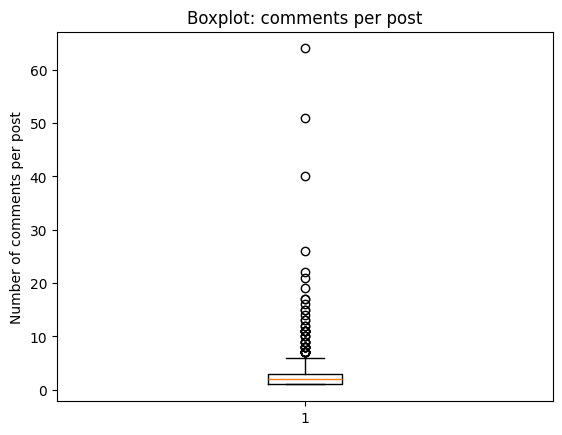

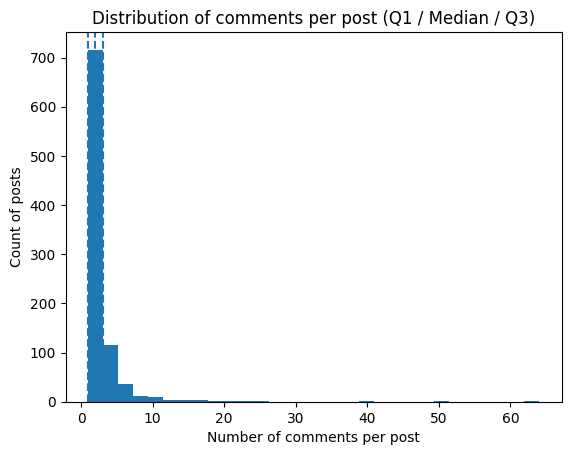


Sanity check:
Average absolute difference between num_comments_listed and computed = 2.903973509933775
Posts where they differ = 713


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POSTS_PATH = "../data/Ambivalent_posts_with_top10_comments_Final.csv"
COMMENTS_PATH = "../data/Ambivalent_Comments_d0.csv"

posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

# 1) True comment count per post from the comments file
comment_counts = (
    comments.groupby("post_id")
    .size()
    .rename("num_comments_from_comments_file")
    .reset_index()
)

# 2) Attach to posts (so every post gets a count, missing -> 0)
df = posts[["post_id", "num_comments_listed"]].merge(comment_counts, on="post_id", how="left")
df["num_comments_from_comments_file"] = df["num_comments_from_comments_file"].fillna(0).astype(int)

x = df["num_comments_from_comments_file"].to_numpy()

# 3) Percentiles / quartiles
ps = [0, 10, 25, 50, 75, 90, 100]
vals = np.percentile(x, ps)

print("Percentiles for number of comments per post (computed from comments file):")
for p, v in zip(ps, vals):
    print(f"{p:>3}th percentile = {v:.0f}")

q1, med, q3 = np.percentile(x, [25, 50, 75])
print(f"\nQ1 (25%) = {q1:.0f}")
print(f"Median (50%) = {med:.0f}")
print(f"Q3 (75%) = {q3:.0f}")
print(f"IQR = {q3 - q1:.0f}")
print(f"Min = {x.min()}, Max = {x.max()}")
print(f"Number of posts = {len(x)}")

# 4) Boxplot (matches what your advisor showed)
plt.figure()
plt.boxplot(x, vert=True, showfliers=True)
plt.ylabel("Number of comments per post")
plt.title("Boxplot: comments per post")
plt.show()

# 5) Optional: histogram to "see" the distribution shape
plt.figure()
plt.hist(x, bins=30)
plt.axvline(q1, linestyle="--")
plt.axvline(med, linestyle="--")
plt.axvline(q3, linestyle="--")
plt.xlabel("Number of comments per post")
plt.ylabel("Count of posts")
plt.title("Distribution of comments per post (Q1 / Median / Q3)")
plt.show()

# 6) Optional sanity check: compare listed vs computed counts
# (If num_comments_listed is from Reddit metadata, it may not exactly match your extracted comments.)
diff = (df["num_comments_listed"].fillna(0).astype(int) - df["num_comments_from_comments_file"]).abs()
print("\nSanity check:")
print("Average absolute difference between num_comments_listed and computed =", diff.mean())
print("Posts where they differ =", (diff > 0).sum())


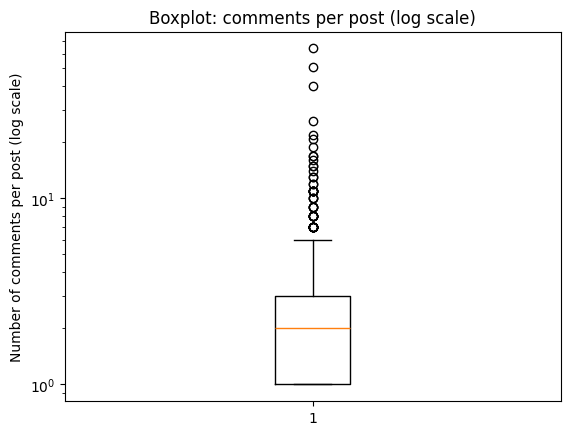

In [3]:
plt.figure()
plt.boxplot(x, vert=True, showfliers=True)
plt.yscale("log")
plt.ylabel("Number of comments per post (log scale)")
plt.title("Boxplot: comments per post (log scale)")
plt.show()


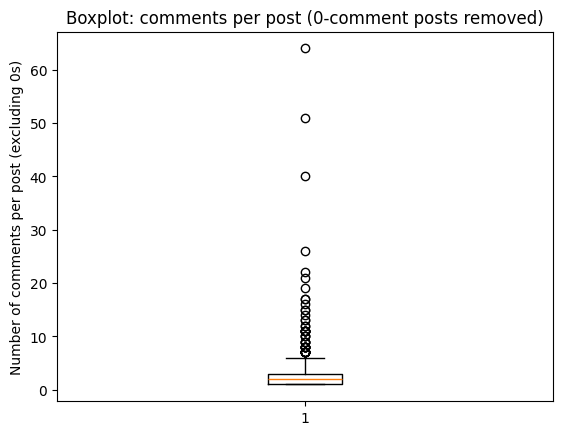

In [4]:
# Remove posts with 0 comments
x_nonzero = x[x > 0]

plt.figure()
plt.boxplot(x_nonzero, vert=True, showfliers=True)
plt.ylabel("Number of comments per post (excluding 0s)")
plt.title("Boxplot: comments per post (0-comment posts removed)")
plt.show()

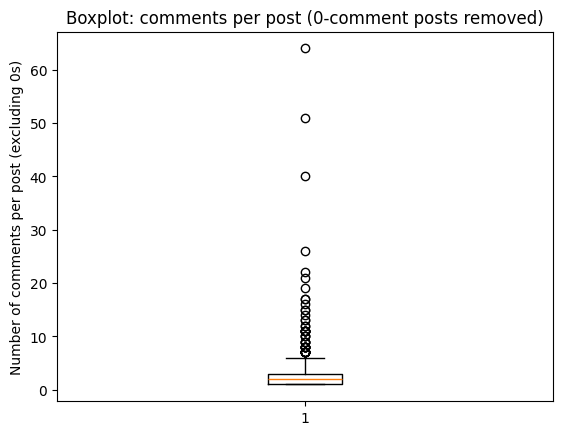

Posts kept: 906 out of 906


In [5]:
df_nonzero = df[df["num_comments_from_comments_file"] > 0].copy()
x_nonzero = df_nonzero["num_comments_from_comments_file"].to_numpy()

plt.figure()
plt.boxplot(x_nonzero, vert=True, showfliers=True)
plt.ylabel("Number of comments per post (excluding 0s)")
plt.title("Boxplot: comments per post (0-comment posts removed)")
plt.show()

print("Posts kept:", len(df_nonzero), "out of", len(df))


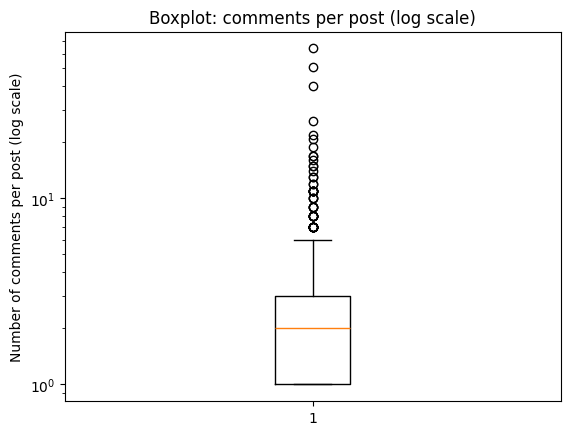

In [6]:
plt.figure()
plt.boxplot(x, vert=True, showfliers=True)
plt.yscale("log")
plt.ylabel("Number of comments per post (log scale)")
plt.title("Boxplot: comments per post (log scale)")
plt.show()


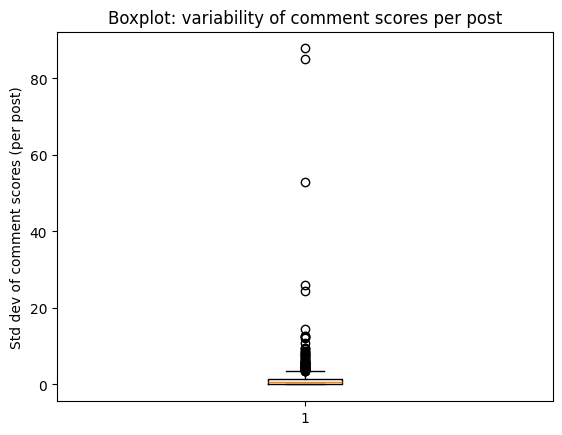

Posts with >=2 comments (std defined): 993 out of 1471
Min/Median/Max std: 0.0 0.7071067811865476 87.80743689475271


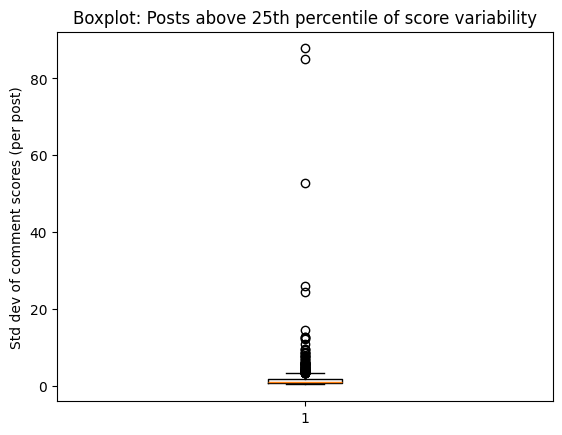

25th percentile (Q1): 0.0
Posts above Q1: 729 out of 993
Min/Median/Max (above Q1): 0.2672612419124244 0.8944271909999159 87.80743689475271


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POSTS_PATH = "../data/Ambivalent_Data_Final.csv"
COMMENTS_PATH = "../data/Ambivalent_Comments_Final.csv"

posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

# 1) Compute per-post std dev of comment scores
# NOTE: std is NaN for posts with < 2 comments
score_std = (
    comments.groupby("post_id")["comment_score"]
    .std(ddof=1)  # sample std; pandas default
    .rename("comment_score_std")
    .reset_index()
)

# 2) Merge so we keep only posts in your posts file (optional but nice)
df_std = posts[["post_id"]].merge(score_std, on="post_id", how="left")

# Option A (recommended): keep only posts with >=2 comments (std exists)
std_vals = df_std["comment_score_std"].dropna().to_numpy()

plt.figure()
plt.boxplot(std_vals, vert=True, showfliers=True)
plt.ylabel("Std dev of comment scores (per post)")
plt.title("Boxplot: variability of comment scores per post")
plt.show()

print("Posts with >=2 comments (std defined):", len(std_vals), "out of", len(df_std))
print("Min/Median/Max std:", np.min(std_vals), np.median(std_vals), np.max(std_vals))

# Compute 25th percentile (Q1)
q1 = np.percentile(std_vals, 25)

# Keep only posts above the 25th percentile
std_vals_above_q1 = std_vals[std_vals > q1]

plt.figure()
plt.boxplot(std_vals_above_q1, vert=True, showfliers=True)
plt.ylabel("Std dev of comment scores (per post)")
plt.title("Boxplot: Posts above 25th percentile of score variability")
plt.show()

print("25th percentile (Q1):", q1)
print("Posts above Q1:", len(std_vals_above_q1), "out of", len(std_vals))
print(
    "Min/Median/Max (above Q1):",
    np.min(std_vals_above_q1),
    np.median(std_vals_above_q1),
    np.max(std_vals_above_q1),
)



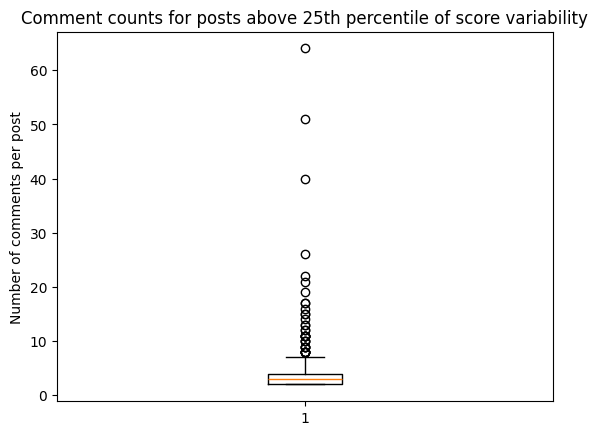

25th percentile of score std: 0.0
Posts above Q1: 450
Min / Median / Max comments: 2 3.0 64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
POSTS_PATH = "../data/Ambivalent_Data_Final.csv"
COMMENTS_PATH = "../data/Ambivalent_Comments_d0.csv"

# Load data
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

# --- 1. Compute per-post std dev of comment scores ---
score_std = (
    comments.groupby("post_id")["comment_score"]
    .std(ddof=1)
    .rename("comment_score_std")
    .reset_index()
)

df_std = posts[["post_id"]].merge(score_std, on="post_id", how="left")

# Keep only posts with >=2 comments
std_vals = df_std["comment_score_std"].dropna()

# --- 2. Compute 25th percentile and filter posts ---
q1 = np.percentile(std_vals, 25)

high_var_posts = df_std.loc[
    df_std["comment_score_std"] > q1, "post_id"
]

# --- 3. Count comments per post ---
comment_counts = (
    comments.groupby("post_id")
    .size()
    .rename("num_comments")
    .reset_index()
)

# Keep only high-variability posts
high_var_comment_counts = (
    comment_counts[comment_counts["post_id"].isin(high_var_posts)]
    ["num_comments"]
    .to_numpy()
)

# --- 4. Plot number of comments ---
plt.figure()
plt.boxplot(high_var_comment_counts, vert=True, showfliers=True)
plt.ylabel("Number of comments per post")
plt.title("Comment counts for posts above 25th percentile of score variability")
plt.show()

# --- 5. Print summary stats ---
print("25th percentile of score std:", q1)
print("Posts above Q1:", len(high_var_comment_counts))
print(
    "Min / Median / Max comments:",
    np.min(high_var_comment_counts),
    np.median(high_var_comment_counts),
    np.max(high_var_comment_counts),
)


In [13]:
import numpy as np

# Reuse std_vals from previous cell (posts with >=2 comments)
q25, q50, q75 = np.percentile(std_vals, [25, 50, 75])

counts = {
    "25–50%": np.sum((std_vals > q25) & (std_vals <= q50)),
    "50–75%": np.sum((std_vals > q50) & (std_vals <= q75)),
    "75–100%": np.sum(std_vals > q75),
}

print("Score variability percentile cutoffs:")
print(f"25% = {q25:.4f}, 50% = {q50:.4f}, 75% = {q75:.4f}\n")

print("Number of posts in each percentile range:")
for k, v in counts.items():
    print(f"{k}: {v}")


Score variability percentile cutoffs:
25% = 0.0000, 50% = 0.7071, 75% = 2.1213

Number of posts in each percentile range:
25–50%: 165
50–75%: 174
75–100%: 144


In [14]:
import numpy as np
import pandas as pd

# Assumptions from previous cells:
# - posts: full posts dataframe (ALL columns)
# - df_std: post_id + comment_score_std
# - std_vals derived from df_std["comment_score_std"].dropna()

# --- 1) Compute percentile cutoffs ---
q25, q50, q75 = np.percentile(std_vals, [25, 50, 75])

print("Score variability percentile cutoffs:")
print(f"25% = {q25:.4f}, 50% = {q50:.4f}, 75% = {q75:.4f}\n")

# --- 2) Attach std values back to full posts ---
posts_with_std = posts.merge(
    df_std[["post_id", "comment_score_std"]],
    on="post_id",
    how="left"
)

# Keep only posts with defined std (>=2 comments)
posts_with_std = posts_with_std.dropna(subset=["comment_score_std"])

# --- 3) Create buckets (ROWS ONLY) ---
posts_25_50 = posts_with_std[
    (posts_with_std["comment_score_std"] > q25) &
    (posts_with_std["comment_score_std"] <= q50)
]

posts_50_75 = posts_with_std[
    (posts_with_std["comment_score_std"] > q50) &
    (posts_with_std["comment_score_std"] <= q75)
]

posts_75_100 = posts_with_std[
    posts_with_std["comment_score_std"] > q75
]

# --- 4) Drop helper column to preserve EXACT schema ---
posts_25_50 = posts_25_50[posts.columns]
posts_50_75 = posts_50_75[posts.columns]
posts_75_100 = posts_75_100[posts.columns]

# --- 5) Save CSVs ---
posts_25_50.to_csv("Ambivalent_posts_scoreVar_25_50.csv", index=False)
posts_50_75.to_csv("Ambivalent_posts_scoreVar_50_75.csv", index=False)
posts_75_100.to_csv("Ambivalent_posts_scoreVar_75_100.csv", index=False)

# --- 6) Sanity checks ---
print("Saved files:")
print("25–50%:", len(posts_25_50))
print("50–75%:", len(posts_50_75))
print("75–100%:", len(posts_75_100))
print("\nColumns preserved exactly:")
print(list(posts_25_50.columns))


Score variability percentile cutoffs:
25% = 0.0000, 50% = 0.7071, 75% = 2.1213

Saved files:
25–50%: 195
50–75%: 194
75–100%: 160

Columns preserved exactly:
['post_id', 'subreddit', 'title', 'author', 'score', 'num_comments_listed', 'op_replied', 'op_reply_count', 'created_utc', 'permalink', 'body', 'combined_text', 'matched_ambivalent_phrases', 'matched_keywords']


In [10]:
import numpy as np

p30, p40 = np.percentile(std_vals, [30, 40])

print(f"30th percentile (std dev of comment scores) = {p30:.4f}")
print(f"40th percentile (std dev of comment scores) = {p40:.4f}")


30th percentile (std dev of comment scores) = 0.4472
40th percentile (std dev of comment scores) = 0.5774


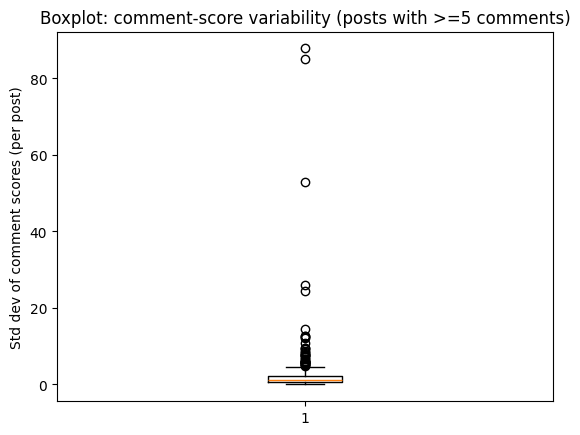

Posts with >=5 comments: 382


In [12]:
comment_counts = comments.groupby("post_id").size().rename("num_comments").reset_index()

tmp = posts[["post_id"]].merge(comment_counts, on="post_id", how="left").fillna({"num_comments": 0})
tmp = tmp.merge(score_std, on="post_id", how="left")

std_vals_5plus = tmp.loc[tmp["num_comments"] >= 5, "comment_score_std"].dropna().to_numpy()

plt.figure()
plt.boxplot(std_vals_5plus, vert=True, showfliers=True)
plt.ylabel("Std dev of comment scores (per post)")
plt.title("Boxplot: comment-score variability (posts with >=5 comments)")
plt.show()

print("Posts with >=5 comments:", len(std_vals_5plus))


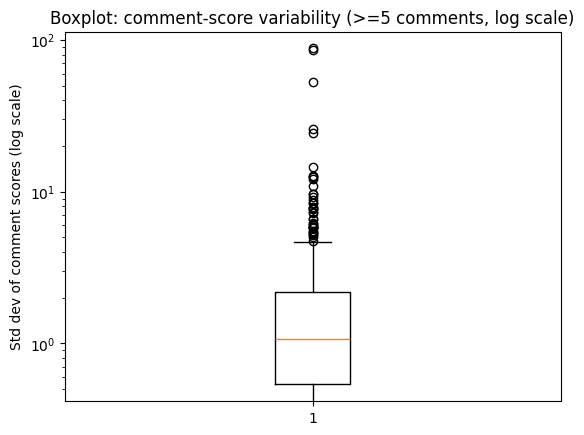

In [10]:
plt.figure()
plt.boxplot(std_vals_5plus, vert=True, showfliers=True)
plt.yscale("log")
plt.ylabel("Std dev of comment scores (log scale)")
plt.title("Boxplot: comment-score variability (>=5 comments, log scale)")
plt.show()


In [11]:
import numpy as np

# std_vals_5plus = ... (your array of per-post std devs for posts with >=5 comments)

ps = [0, 10, 25, 50, 75, 90, 95, 99, 100]
vals = np.percentile(std_vals_5plus, ps)

print("Percentiles for std dev of comment scores (posts with >=5 comments):")
for p, v in zip(ps, vals):
    print(f"{p:>3}th percentile = {v:.4f}")

q1, med, q3 = np.percentile(std_vals_5plus, [25, 50, 75])
print(f"\nQ1 (25%) = {q1:.4f}")
print(f"Median (50%) = {med:.4f}")
print(f"Q3 (75%) = {q3:.4f}")
print(f"IQR = {(q3 - q1):.4f}")
print(f"Count of posts (>=5 comments) = {len(std_vals_5plus)}")


Percentiles for std dev of comment scores (posts with >=5 comments):
  0th percentile = 0.0000
 10th percentile = 0.3333
 25th percentile = 0.5345
 50th percentile = 1.0607
 75th percentile = 2.1925
 90th percentile = 4.9520
 95th percentile = 7.7175
 99th percentile = 24.6469
100th percentile = 87.8074

Q1 (25%) = 0.5345
Median (50%) = 1.0607
Q3 (75%) = 2.1925
IQR = 1.6580
Count of posts (>=5 comments) = 382
